In [21]:
# Task : Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Task : Load Dataset

df = pd.read_csv("Pharma_Industry.csv")

print(df.head())

   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  


In [23]:
# Task : Display Dataset Information

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB
None


In [24]:
# Task : Statistical Summary

print(df.describe())

       Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
count        500.000000                      500.000000        500.000000   
mean          -0.037761                        0.214957          0.062871   
std            0.979891                        1.247567          0.971978   
min           -3.019512                       -3.773897         -2.940389   
25%           -0.642003                       -0.565168         -0.648157   
50%           -0.019340                        0.201532          0.027732   
75%            0.641151                        0.951375          0.710774   
max            2.949094                        4.111751          3.193108   

       Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
count                  500.000000                   500.000000       500.0000  
mean                     0.054398                    -0.171863         0.5200  
std                      0.986001                     0.983765    

In [25]:
# Task : Check Missing Values

print(df.isnull().sum())

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64


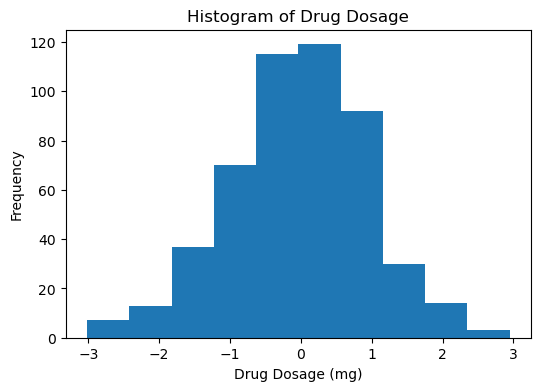

In [26]:
# Task : Histogram for Drug Dosage

plt.figure(figsize=(6,4))

plt.hist(df['Drug Dosage (mg)'], bins=10)

plt.title("Histogram of Drug Dosage")
plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Frequency")

plt.show()

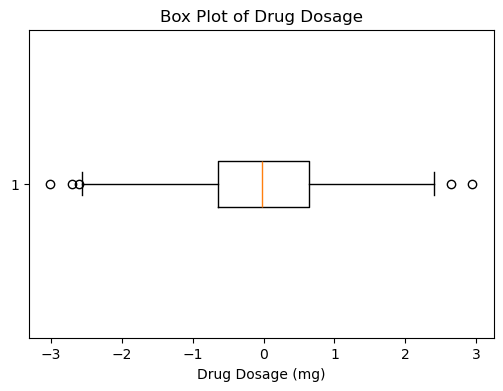

In [27]:
# Task : Box Plot for Drug Dosage

plt.figure(figsize=(6,4))

plt.boxplot(df['Drug Dosage (mg)'].dropna(), vert=False)

plt.title("Box Plot of Drug Dosage")
plt.xlabel("Drug Dosage (mg)")

plt.show()

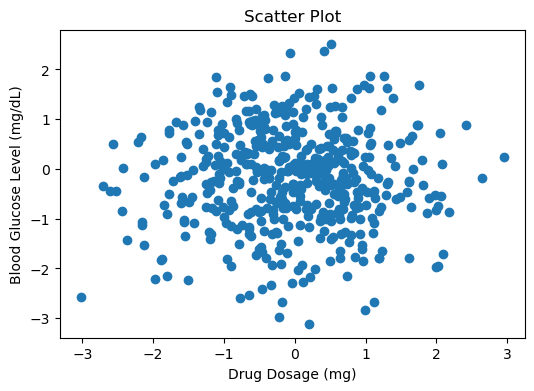

In [28]:
# Task : Scatter Plot

plt.figure(figsize=(6,4))

plt.scatter(
    df['Drug Dosage (mg)'],
    df['Blood Glucose Level (mg/dL)']
)

plt.title("Scatter Plot")

plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Blood Glucose Level (mg/dL)")

plt.show()

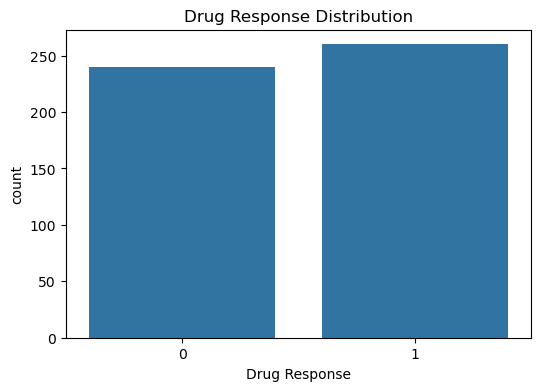

In [29]:
# Task :  Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='Drug Response', data=df)

plt.title("Drug Response Distribution")

plt.show()

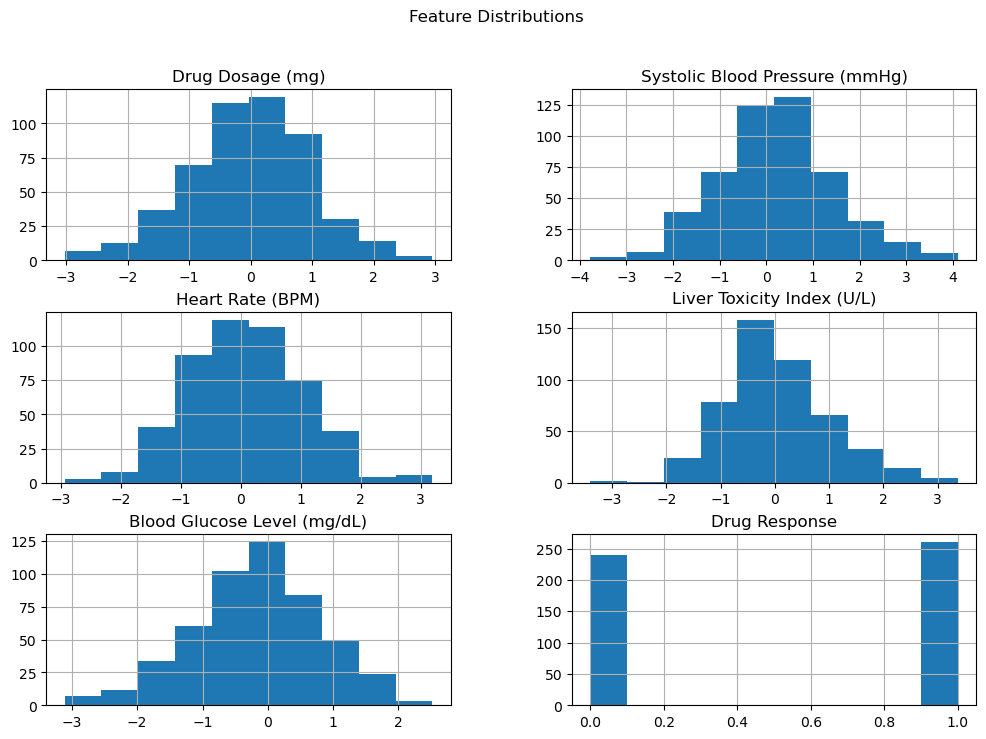

In [30]:
# Task: Density Plots for Feature Distribution

import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.suptitle("Feature Distributions")
plt.show()

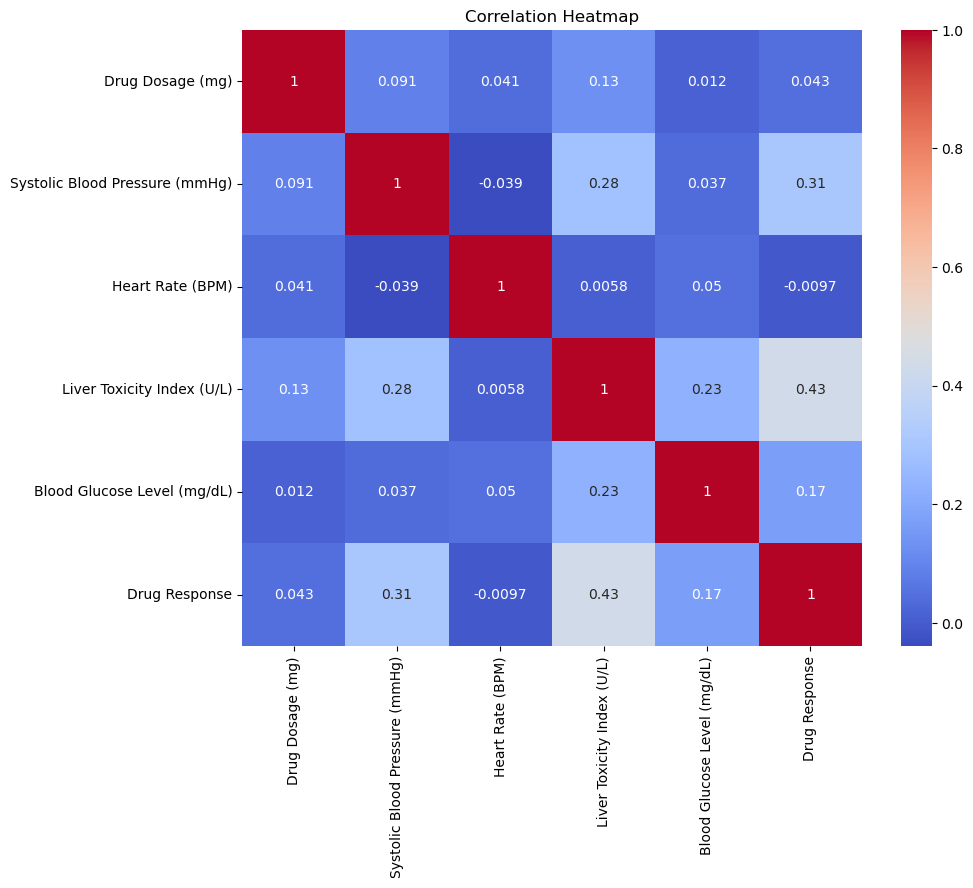

In [40]:
# Task: Correlation Analysis

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

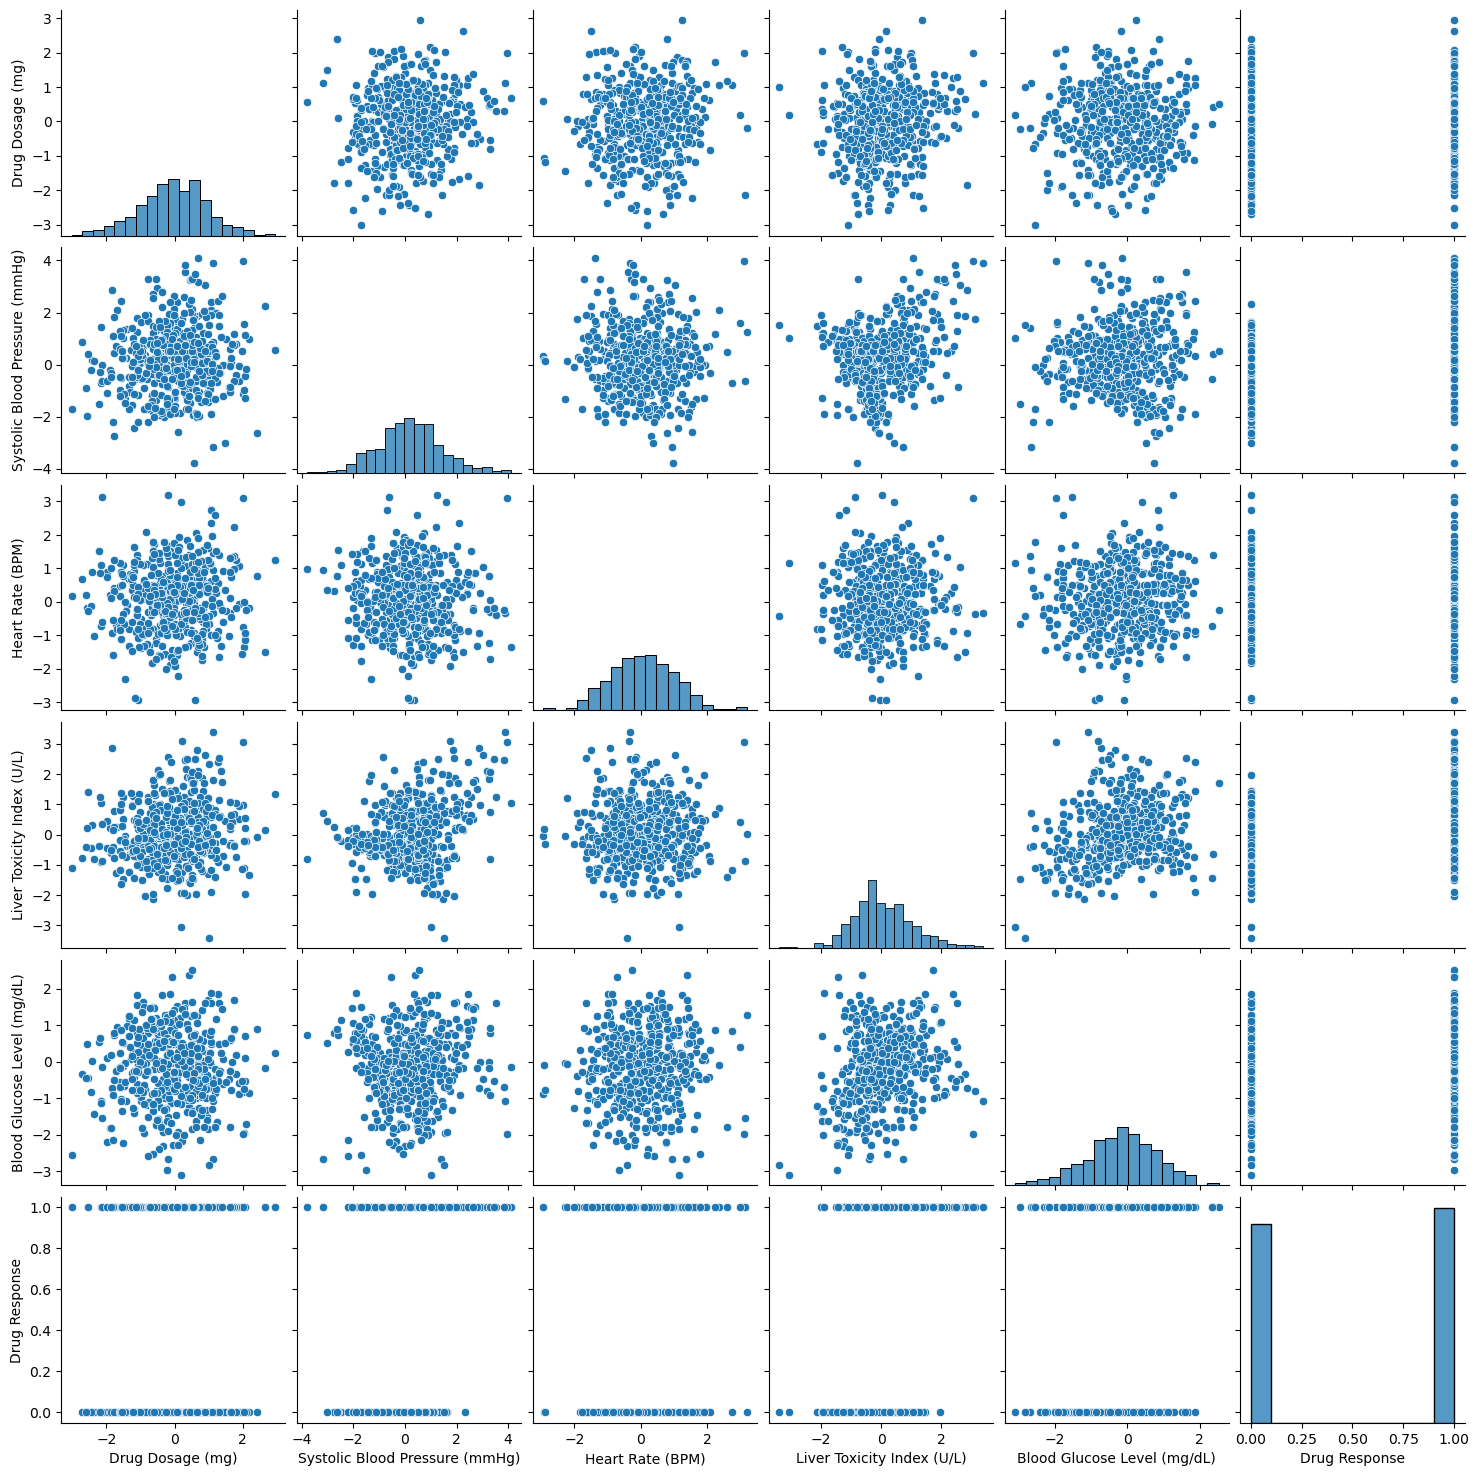

In [50]:
# Task: Pair Plot Visualization

sns.pairplot(df[['Drug Dosage (mg)','Systolic Blood Pressure (mmHg)','Heart Rate (BPM)','Liver Toxicity Index (U/L)','Blood Glucose Level (mg/dL)','Drug Response']])
plt.show()

In [47]:
# Task : Encode Categorical Variables

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print(df.head())

   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  


In [32]:
# Task : Define Features and Target Variable

X = df.drop('Drug Response', axis=1)

y = df['Drug Response']

In [33]:
# Task : Split Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(400, 5)
(100, 5)


In [34]:
# Task : Apply Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [35]:
# Task : Train SVM Model

from sklearn.svm import SVC

svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

print("SVM Model Training Completed")

SVM Model Training Completed


In [36]:
# Task : Predict Testing Data

y_pred = svm_model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


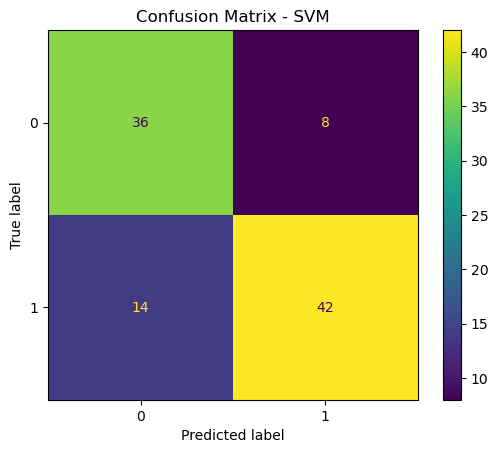

In [51]:
# Task: Visualize Classification Results

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - SVM")
plt.show()

In [37]:
# Task : Evaluate Model Performance

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.78
Precision: 0.84
Recall: 0.75
F1 Score: 0.7924528301886793


In [38]:
# Task : Compare Different Kernels

linear_model = SVC(kernel='linear')

poly_model = SVC(kernel='poly')

rbf_model = SVC(kernel='rbf')

linear_model.fit(X_train, y_train)

poly_model.fit(X_train, y_train)

rbf_model.fit(X_train, y_train)

linear_accuracy = accuracy_score(y_test, linear_model.predict(X_test))

poly_accuracy = accuracy_score(y_test, poly_model.predict(X_test))

rbf_accuracy = accuracy_score(y_test, rbf_model.predict(X_test))

print("Linear Kernel Accuracy:", linear_accuracy)

print("Polynomial Kernel Accuracy:", poly_accuracy)

print("RBF Kernel Accuracy:", rbf_accuracy)

Linear Kernel Accuracy: 0.78
Polynomial Kernel Accuracy: 0.71
RBF Kernel Accuracy: 0.84


In [39]:
# Task : Parameter Tuning

tuned_model = SVC(kernel='rbf', C=10, gamma=0.1)

tuned_model.fit(X_train, y_train)

tuned_pred = tuned_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)

print("Tuned Model Accuracy:", tuned_accuracy)

Tuned Model Accuracy: 0.84


In [52]:
# Task: Compare Different Kernels

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

kernels = ['linear', 'poly', 'rbf']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print(f"{k} Kernel Accuracy:",
          accuracy_score(y_test, pred))

linear Kernel Accuracy: 0.78
poly Kernel Accuracy: 0.71
rbf Kernel Accuracy: 0.84


In [53]:
# Task: SVM Analysis Report

print("SVM Analysis Report")

print("\nStrengths:")
print("- Effective for classification problems.")
print("- Works well with high-dimensional data.")
print("- Can use different kernels for complex relationships.")

print("\nWeaknesses:")
print("- Training can be slower on large datasets.")
print("- Sensitive to parameter selection.")
print("- Less interpretable than simple models.")

print("\nPractical Implications:")
print("- Useful for medical diagnosis, drug response prediction, and classification tasks.")
print("- Kernel selection can significantly affect model performance.")

SVM Analysis Report

Strengths:
- Effective for classification problems.
- Works well with high-dimensional data.
- Can use different kernels for complex relationships.

Weaknesses:
- Training can be slower on large datasets.
- Sensitive to parameter selection.
- Less interpretable than simple models.

Practical Implications:
- Useful for medical diagnosis, drug response prediction, and classification tasks.
- Kernel selection can significantly affect model performance.
